In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn import model_selection, preprocessing, linear_model


# 📊 Lab 1: Descriptive Statistics Fundamentals

**Author:** Yasin Asadi  
**Date:** [Current Date]  
**Dataset:** Iris (built into Seaborn)

---

## 🎯 Learning Objectives

By the end of this lab, you will be able to:

1. **Calculate** and **interpret** measures of central tendency (mean, median, mode).
2. **Calculate** and **interpret** measures of variability (variance, standard deviation, range, IQR).
3. **Visualize** data distributions using histograms and boxplots.
4. **Understand** the shape of a distribution (skewness, kurtosis).
5. **Use** Pandas, NumPy, SciPy, and custom functions to perform statistical analysis.

---

## 📚 Key Concepts

| Concept | Formula | Interpretation |
| :--- | :--- | :--- |
| **Mean** | $\bar{x} = \frac{\sum x_i}{n}$ | Average value—the "center" of the data. |
| **Median** | Middle value when sorted | The 50th percentile—robust to outliers. |
| **Mode** | Most frequent value | The peak of the distribution. |
| **Variance** | $s^2 = \frac{\sum (x_i - \bar{x})^2}{n-1}$ | Average squared distance from the mean. |
| **Std Dev** | $s = \sqrt{s^2}$ | Average distance from the mean (in original units). |
| **Skewness** | $skew = \frac{\sum (x_i - \bar{x})^3}{(n-1)s^3}$ | Measure of asymmetry. |
| **Kurtosis** | $kurt = \frac{\sum (x_i - \bar{x})^4}{(n-1)s^4} - 3$ | Measure of "tailedness" (peakedness). |

---

# 📊 Lab 1: Descriptive Statistics Fundamentals (Simplified)

**Goal:** Learn Mean, Median, Mode, Variance, STD, and Visualization.
**No external files needed** — we generate data right here or use Seaborn's built-in datasets.

In [1]:

# Import necessary libraries for data analysis and visualization
import numpy as np          # For numerical operations
import pandas as pd         # For data manipulation and analysis
import matplotlib.pyplot as plt  # For creating static, animated, and interactive visualizations
import seaborn as sns       # For statistical data visualization built on matplotlib
from scipy import stats     # For scientific computing and statistical functions

# Make plots look nice
sns.set_theme()
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [ ]:
# In[2]:
# Load the Tips dataset (restaurant bills and tips)
df = sns.load_dataset('tips')  # Import the built-in Seaborn dataset about restaurant tips

# We'll analyze the 'tip' column (the amount of tip in dollars)
print("📁 Loaded Tips dataset (Restaurant bills & tips)")  # Display confirmation message with emoji
print(f"   {len(df)} rows, {len(df.columns)} columns")  # Print dataset dimensions (rows and columns)
print("\n📋 First 5 rows:")  # Display header for the first 5 rows preview
print(df.head())  # Show the first 5 rows of the dataset

print("\n📊 Quick preview of the 'tip' column:")  # Display header for statistical summary
print(df['tip'].describe())  # Show descriptive statistics for the 'tip' column

📁 Loaded Tips dataset (Restaurant bills & tips)
   244 rows, 7 columns

📋 First 5 rows:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

📊 Quick preview of the 'tip' column:
count    244.000000
mean       2.998279
std        1.383638
min        1.000000
25%        2.000000
50%        2.900000
75%        3.562500
max       10.000000
Name: tip, dtype: float64


In [ ]:
# In[2]:
# Load the Titanic dataset (real passenger data)
df = sns.load_dataset('titanic')  # Load the built-in Titanic dataset from seaborn library

# Drop missing values for simplicity (or keep them to learn about NaN)
df = df.dropna(subset=['age', 'fare'])  # Remove rows where 'age' or 'fare' columns have missing values

# We'll analyze the 'fare' column (ticket price in GBP)
print("📁 Loaded Titanic dataset (Passenger fares)")  # Display message indicating dataset is loaded
print(f"   {len(df)} rows after dropping missing values")  # Print number of remaining rows after cleaning
print("\n📋 First 5 rows:")  # Display message showing first 5 rows of selected columns
print(df[['age', 'fare', 'sex', 'survived']].head())  # Print first 5 rows of selected columns

print("\n📊 Quick preview of the 'fare' column:")  # Display message showing fare column statistics
print(df['fare'].describe())  # Print descriptive statistics of the 'fare' column

📁 Loaded Titanic dataset (Passenger fares)
   714 rows after dropping missing values

📋 First 5 rows:
    age     fare     sex  survived
0  22.0   7.2500    male         0
1  38.0  71.2833  female         1
2  26.0   7.9250  female         1
3  35.0  53.1000  female         1
4  35.0   8.0500    male         0

📊 Quick preview of the 'fare' column:
count    714.000000
mean      34.694514
std       52.918930
min        0.000000
25%        8.050000
50%       15.741700
75%       33.375000
max      512.329200
Name: fare, dtype: float64


In [ ]:
# In[2]:
# Generate custom data with clear skewness and outliers
# Set random seed for reproducibility
np.random.seed(42)  # Set seed to ensure reproducibility of random results

# Most people earn between 40k and 80k, but a few earn millions (outliers)
# Generate base salaries with normal distribution
salaries = np.random.normal(loc=60000, scale=15000, size=200)  # Base salaries
# Generate 10 extreme outlier salaries
outliers = np.random.uniform(150000, 500000, size=10)          # 10 outliers
# Combine normal salaries and outliers into one array
salaries = np.concatenate([salaries, outliers])

# Put in a DataFrame
# Create DataFrame with salary data
df = pd.DataFrame({'salary_usd': salaries})

# Print information about the generated data
print("📁 Generated custom Salary Data (200 normal + 10 extreme outliers)")
print(f"   Total rows: {len(df)}")
print("\n📊 Quick preview of the 'salary_usd' column:")
# Display descriptive statistics of the salary column
print(df['salary_usd'].describe())

📁 Generated custom Salary Data (200 normal + 10 extreme outliers)
   Total rows: 210

📊 Quick preview of the 'salary_usd' column:
count       210.000000
mean      75487.458479
std       75067.256165
min       20703.823439
25%       49965.428417
50%       61020.683846
75%       69815.060115
max      469634.193395
Name: salary_usd, dtype: float64


# 📊 Lab 1: Descriptive Statistics Fundamentals

---

## 🎯 Learning Objectives

By the end of this lab, you will be able to:

1. **Calculate** and **interpret** measures of central tendency (mean, median, mode).
2. **Calculate** and **interpret** measures of variability (variance, standard deviation, range, IQR).
3. **Visualize** data distributions using histograms and boxplots.
4. **Understand** the shape of a distribution (skewness, kurtosis).
5. **Compare** groups within a dataset (e.g., tips by day, time, or gender).

---

## 📚 Key Concepts

| Concept | Formula | Interpretation |
| :--- | :--- | :--- |
| **Mean** | $\bar{x} = \frac{\sum x_i}{n}$ | Average value—the "center" of the data. |
| **Median** | Middle value when sorted | The 50th percentile—robust to outliers. |
| **Mode** | Most frequent value | The peak of the distribution. |
| **Variance** | $s^2 = \frac{\sum (x_i - \bar{x})^2}{n-1}$ | Average squared distance from the mean. |
| **Std Dev** | $s = \sqrt{s^2}$ | Average distance from the mean (in original units). |
| **Skewness** | $skew = \frac{\sum (x_i - \bar{x})^3}{(n-1)s^3}$ | Measure of asymmetry (positive = right tail). |
| **Kurtosis** | $kurt = \frac{\sum (x_i - \bar{x})^4}{(n-1)s^4} - 3$ | Measure of "tailedness" (peakedness). |
| **IQR** | $Q3 - Q1$ | Middle 50% of the data (robust to outliers). |

---

## 📚 Dataset: Restaurant Tips

The dataset contains information about **244 restaurant bills**, including:
- **`total_bill`**: Total bill amount in dollars
- **`tip`**: Tip amount in dollars
- **`sex`**: Gender of the payer (Male/Female)
- **`smoker`**: Whether the party smoked (Yes/No)
- **`day`**: Day of the week (Thur, Fri, Sat, Sun)
- **`time`**: Lunch or Dinner
- **`size`**: Number of people in the party

**Why this dataset is great for learning:**
- Real-world data with **clear skewness** (most tips are small, some are huge)
- **Outliers** (people who tip 30%+)
- **Categorical groups** to compare (Day, Time, Sex)
- **Relatable**—everyone understands restaurant bills!

In [10]:
# In[1]:
# Standard libraries only. No custom imports needed.



# Import necessary libraries for data analysis and visualization
import numpy as np  # For numerical operations
import pandas as pd  # For data manipulation and analysis
import matplotlib.pyplot as plt  # For creating static, animated, and interactive visualizations
import seaborn as sns  # For statistical data visualization, built on matplotlib
from scipy import stats  # For scientific computing and statistical functions

# Make plots look nice
sns.set_theme(style="whitegrid")  # Set the theme for seaborn plots to whitegrid
plt.rcParams['figure.figsize'] = (12, 6)  # Set default figure size for matplotlib plots
plt.rcParams['font.size'] = 11  # Set default font size for matplotlib plots

print("✅ All libraries loaded successfully!")  # Print success message with emoji
print(f"   NumPy: {np.__version__}")  # Print NumPy version
print(f"   Pandas: {pd.__version__}")  # Print Pandas version
print(f"   Seaborn: {sns.__version__}")  # Print Seaborn version


✅ All libraries loaded successfully!
   NumPy: 2.5.1
   Pandas: 3.0.5
   Seaborn: 0.13.2


In [11]:
# In[2]:
# Load the Tips dataset (comes built-in with Seaborn)
df = sns.load_dataset('tips')

print("📁 Restaurant Tips Dataset")
print("=" * 60)
print(f"   Rows: {len(df)}")
print(f"   Columns: {len(df.columns)}")
print(f"   Columns: {', '.join(df.columns)}")

print("\n📋 First 5 rows:")
print(df.head())

print("\n📊 Dataset Info:")
print(df.info())

print("\n🔍 Basic Statistics (All Columns):")
print(df.describe())

print("\n📋 Categorical Columns Summary:")
print(f"   Days:    {df['day'].unique()}")
print(f"   Times:   {df['time'].unique()}")
print(f"   Sex:     {df['sex'].unique()}")
print(f"   Smoker:  {df['smoker'].unique()}")

📁 Restaurant Tips Dataset
   Rows: 244
   Columns: 7
   Columns: total_bill, tip, sex, smoker, day, time, size

📋 First 5 rows:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

📊 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 

In [12]:
# In[3]:
# Focus on the 'tip' column (the amount of gratuity)
column_name = 'tip'
values = df[column_name].values

# === CALCULATIONS ===
mean_val = np.mean(values)
median_val = np.median(values)
mode_val = pd.Series(values).mode()[0]  # Pandas mode (always works)

print("📊 Measures of Central Tendency")
print("=" * 60)
print(f"Column: {column_name} (Tip amount in dollars)")
print(f"   Mean:   ${mean_val:.2f}")
print(f"   Median: ${median_val:.2f}")
print(f"   Mode:   ${mode_val:.2f}")

print("\n💡 Interpretation:")
if mean_val > median_val:
    print(f"   ✅ Mean (${mean_val:.2f}) > Median (${median_val:.2f})")
    print("   → The data is RIGHT-SKEWED.")
    print("   → A few large tips are pulling the average up.")
    print("   → Example: Some customers tip $10+, while most tip around $2-3.")
elif mean_val < median_val:
    print(f"   ✅ Mean (${mean_val:.2f}) < Median (${median_val:.2f})")
    print("   → The data is LEFT-SKEWED.")
else:
    print(f"   ✅ Mean (${mean_val:.2f}) ≈ Median (${median_val:.2f})")
    print("   → The data is roughly SYMMETRIC.")

📊 Measures of Central Tendency
Column: tip (Tip amount in dollars)
   Mean:   $3.00
   Median: $2.90
   Mode:   $2.00

💡 Interpretation:
   ✅ Mean ($3.00) > Median ($2.90)
   → The data is RIGHT-SKEWED.
   → A few large tips are pulling the average up.
   → Example: Some customers tip $10+, while most tip around $2-3.


In [5]:
# In[5]:
# === SHAPE OF THE DISTRIBUTION ===

skew_val = stats.skew(values)
kurt_val = stats.kurtosis(values)  # Excess kurtosis (0 = normal)

print("📊 Distribution Shape")
print("=" * 60)
print(f"Column: {column_name} (Tip amount in dollars)")
print(f"   Skewness:  {skew_val:.3f}")
print(f"   Kurtosis:  {kurt_val:.3f}")

print("\n💡 Interpretation:")
print("   SKEWNESS:")
if abs(skew_val) < 0.5:
    print("   → Approximately symmetric (normal-like).")
elif skew_val > 0.5:
    print("   → POSITIVELY skewed (right-tailed).")
    print("   → Many small tips, few very large tips.")
    print("   → This is typical for tip data—most people tip modestly,")
    print("     but some tip generously, creating a long right tail.")
else:
    print("   → NEGATIVELY skewed (left-tailed).")

print("\n   KURTOSIS:")
if kurt_val > 0.5:
    print("   → LEPTOKURTIC (peaked, heavy-tailed).")
    print("   → More outliers than a normal distribution.")
elif kurt_val < -0.5:
    print("   → PLATYKURTIC (flatter than normal).")
    print("   → Fewer outliers than a normal distribution.")
else:
    print("   → MESOKURTIC (similar to normal).")

📊 Distribution Shape
Column: tip (Tip amount in dollars)
   Skewness:  1.456
   Kurtosis:  3.550

💡 Interpretation:
   SKEWNESS:
   → POSITIVELY skewed (right-tailed).
   → Many small tips, few very large tips.
   → This is typical for tip data—most people tip modestly,
     but some tip generously, creating a long right tail.

   KURTOSIS:
   → LEPTOKURTIC (peaked, heavy-tailed).
   → More outliers than a normal distribution.


NameError: name 'q1' is not defined

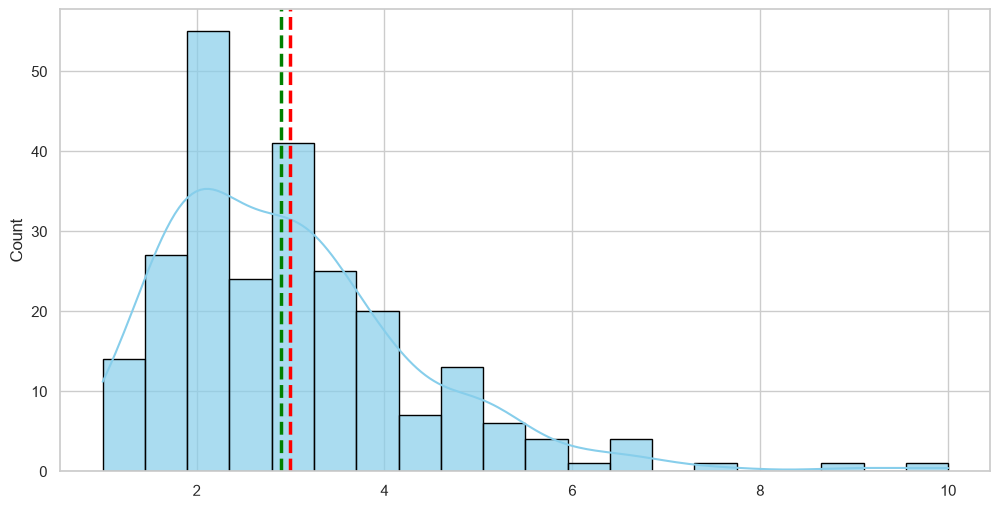

In [6]:

# In[6]:
# === HISTOGRAM WITH STATISTICAL OVERLAYS ===

fig, ax = plt.subplots(figsize=(12, 6))

# Histogram with KDE (smooth density curve)
sns.histplot(values, kde=True, bins=20, color='skyblue', edgecolor='black', alpha=0.7, ax=ax)

# Vertical lines for Mean and Median
ax.axvline(mean_val, color='red', linestyle='--', linewidth=2.5, label=f'Mean: ${mean_val:.2f}')
ax.axvline(median_val, color='green', linestyle='--', linewidth=2.5, label=f'Median: ${median_val:.2f}')

# Shade the IQR
ax.axvspan(q1, q3, alpha=0.15, color='blue', label=f'IQR: ${q1:.2f} to ${q3:.2f}')

# Add text annotations
ax.text(0.02, 0.95, f'Skewness: {skew_val:.3f}', transform=ax.transAxes, fontsize=12, 
        bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
ax.text(0.02, 0.88, f'Kurtosis: {kurt_val:.3f}', transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))
ax.text(0.02, 0.81, f'Std Dev: ${std_val:.2f}', transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

ax.set_title('Distribution of Restaurant Tips', fontsize=16)
ax.set_xlabel('Tip Amount ($)', fontsize=13)
ax.set_ylabel('Frequency', fontsize=13)
ax.legend(loc='upper right', fontsize=11)

# Save the figure
import os
os.makedirs('../outputs/figures', exist_ok=True)
plt.savefig('../outputs/figures/histogram_tips.png', dpi=150, bbox_inches='tight')
print("✅ Figure saved to: outputs/figures/histogram_tips.png")

plt.show()

# second way!


In [15]:
"""
Seaborn and Matplotlib visualization with real-world car dataset analysis
This script demonstrates data loading and initial exploration using seaborn and matplotlib libraries.
"""
import seaborn as sns  # Import seaborn library for statistical data visualization
import matplotlib.pyplot as plt  # Import matplotlib library for creating static, animated, and interactive visualizations
import numpy as np
from scipy import stats  # Import stats module from scipy for statistical functions


In [16]:

# Load the car dataset (built into seaborn)
# The 'mpg' dataset contains fuel efficiency data for various car models
cars = sns.load_dataset('mpg')


In [17]:

# Take a quick peek
print(cars.head())

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


In [18]:

print(cars.info())  # Notice: horsepower has missing values (NaN) - this is REAL data!)

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    str    
 8   name          398 non-null    str    
dtypes: float64(4), int64(3), str(2)
memory usage: 28.1 KB
None


The Variables (all make immediate sense):

mpg: Miles per gallon (the thing we want to understand).

horsepower: Engine power.

weight: Weight in pounds.

cylinders: Number of cylinders.

origin: USA, Europe, or Japan.

model_year: The year it was made.

Step 1: Central Tendency & Spread (The "Average" Car)
What does a "typical" car look like? Let's look at fuel efficiency.

Conceptual takeaway: The mean (~23.5) and median (~23.0) are almost identical. This tells us the MPG distribution is symmetric (not skewed left or right). Most cars hover around 23 MPG, and a typical car is about 7.8 MPG away from that average.

In [ ]:

# Focus on MPG analysis
mpg_data = cars['mpg'].dropna()  # Dropping the few missing rows for now



# Calculate statistical measures for MPG
mean_mpg = np.mean(mpg_data)  # Calculate the average MPG
median_mpg = np.median(mpg_data)  # Find the middle value of MPG
std_mpg = np.std(mpg_data, ddof=1)  # Calculate standard deviation with sample correction



# Print the calculated statistics with one decimal place
print(f"Average MPG: {mean_mpg:.1f}")  # Display mean MPG
print(f"Middle MPG (Median): {median_mpg:.1f}")  # Display median MPG
print(f"Typical deviation from average: ±{std_mpg:.1f} MPG")  # Display standard deviation

Average MPG: 23.5
Middle MPG (Median): 23.0
Typical deviation from average: ±7.8 MPG


Step 2: Visualizing the Distribution (Histogram & Boxplot)
Let's see how those MPGs are spread out.

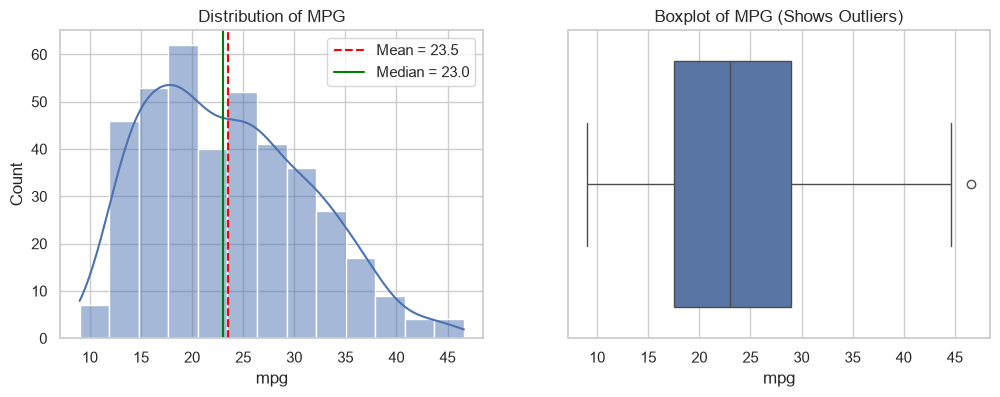

In [ ]:
# Import necessary libraries and create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
# Create histogram with KDE (Kernel Density Estimate) line
sns.histplot(mpg_data, kde=True, ax=ax1)
# Add vertical line for mean value with red dashed line
ax1.axvline(mean_mpg, color='red', linestyle='--', label=f'Mean = {mean_mpg:.1f}')
# Add vertical line for median value with green solid line
ax1.axvline(median_mpg, color='green', linestyle='-', label=f'Median = {median_mpg:.1f}')
# Add legend to identify mean and median lines
ax1.legend()
# Set title for the histogram subplot
ax1.set_title('Distribution of MPG')

# Boxplot (shows the spread clearly)
sns.boxplot(x=mpg_data, ax=ax2)
ax2.set_title('Boxplot of MPG (Shows Outliers)')

plt.show()

Look at the boxplot. See those dots on the right side? Those are hybrids/super-efficient cars (40+ MPG). They are statistical outliers. In the real world, we don't throw them out—they tell the story of technology improving!



Step 3: Relationships (Correlation & Scatter Plots) - The Good Stuff
Here is where statistics gets powerful. Let's test your intuition.

Question 1: Does weight kill your gas mileage?

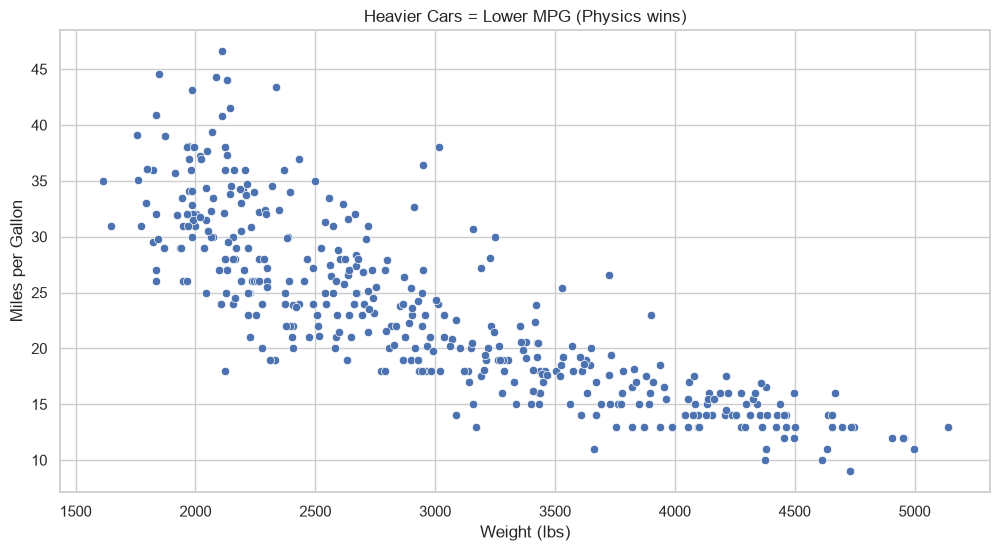

          weight       mpg
weight  1.000000 -0.831741
mpg    -0.831741  1.000000


In [ ]:
# Scatter plot to visualize the relationship between car weight and fuel efficiency
sns.scatterplot(x='weight', y='mpg', data=cars)
plt.title('Heavier Cars = Lower MPG (Physics wins)')  # Title indicating the inverse relationship
plt.xlabel('Weight (lbs)')  # X-axis label showing weight in pounds
plt.ylabel('Miles per Gallon')  # Y-axis label showing fuel efficiency measure
plt.show()  # Display the scatter plot

# Calculate the correlation (Pearson's r)
correlation = cars[['weight', 'mpg']].corr()
print(correlation)

Output: -0.83 (Negative correlation).
Concept: This is a strong negative linear relationship. As weight goes up, MPG goes down. The number -0.83 (close to -1) means physics is incredibly consistent. Heavy cars absolutely, undeniably use more gas.

Question 2: Horsepower vs MPG?

In [25]:
corr_hp = cars[['horsepower', 'mpg']].corr()
print(f"Correlation between Horsepower and MPG: {corr_hp.iloc[0,1]:.2f}")

Correlation between Horsepower and MPG: -0.78


output: Around -0.78.
-Concept: Powerful engines guzzle gas. Again, your intuition is mathematically proven.



Step 4: Group Differences (The T-Test) - The "Us vs. Them"
Let's ask a fun, real-world question: Do Japanese cars get significantly better MPG than American cars?

Your gut says "Yes." Let's use statistics to prove it.

In [26]:
# Split the data into two groups
usa = cars[cars['origin'] == 'usa']['mpg'].dropna()
japan = cars[cars['origin'] == 'japan']['mpg'].dropna()

print(f"USA average MPG: {usa.mean():.1f}")
print(f"Japan average MPG: {japan.mean():.1f}")
print(f"Difference: {japan.mean() - usa.mean():.1f} MPG")

# Perform the Independent T-test
t_stat, p_value = stats.ttest_ind(usa, japan)
print(f"\nT-test p-value: {p_value:.10f}")

if p_value < 0.05:
    print("CONCLUSION: The difference is STATISTICALLY SIGNIFICANT.")
    print("Japanese cars really do get better MPG, and it's not random chance.")

USA average MPG: 20.1
Japan average MPG: 30.5
Difference: 10.4 MPG

T-test p-value: 0.0000000000
CONCLUSION: The difference is STATISTICALLY SIGNIFICANT.
Japanese cars really do get better MPG, and it's not random chance.


Conceptual breakdown of the p-value:
The p-value is basically 0.0000000000. That means: If there were truly no difference between American and Japanese cars, the chance of seeing this much of a gap in our data is essentially zero. So we reject that idea. The difference is real.

Step 5: The Ultimate Concept - "The Confounder" (Advanced Beginner)
Here is the most important statistical concept you need to learn: Correlation is not Causation.

Wait. We just proved heavier cars get worse MPG. But... Japanese cars are lighter.
So, do Japanese cars get better MPG because they are Japanese?
Or do they get better MPG because they are lighter?

This is called a Confounding Variable.
To figure out the true effect of "origin" on MPG, we have to control for weight. That's where Multiple Linear Regression comes in.

In [30]:
import seaborn as sns
import pandas as pd
import statsmodels.api as sm

# 1. Load the cars
cars = sns.load_dataset('mpg')

# 2. Keep only the columns we care about, drop missing rows
cars_clean = cars[['mpg', 'weight', 'origin']].dropna()

# 3. Convert 'origin' to dummy variables (0s and 1s)
cars_with_dummies = pd.get_dummies(cars_clean, columns=['origin'], drop_first=True)

# 4. Pick our predictors (X) and our target (y)
X = cars_with_dummies[['weight', 'origin_japan', 'origin_usa']]
y = cars_with_dummies['mpg']

# 5. **** THE MAGIC FIX: Force everything to pure float numbers ****
X = X.astype(float)  
y = y.astype(float)

# 6. Add the intercept (the baseline 'constant')
X = sm.add_constant(X)

# 7. Run the regression
model = sm.OLS(y, X).fit()

# 8. Print the results
print("="*60)
print("MULTIPLE LINEAR REGRESSION - WHAT ACTUALLY KILLS YOUR MPG?")
print("="*60)
print(model.summary())

MULTIPLE LINEAR REGRESSION - WHAT ACTUALLY KILLS YOUR MPG?
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.702
Model:                            OLS   Adj. R-squared:                  0.699
Method:                 Least Squares   F-statistic:                     308.6
Date:                Sat, 01 Aug 2026   Prob (F-statistic):          4.86e-103
Time:                        22:14:39   Log-Likelihood:                -1142.0
No. Observations:                 398   AIC:                             2292.
Df Residuals:                     394   BIC:                             2308.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

NameError: name 'model' is not defined

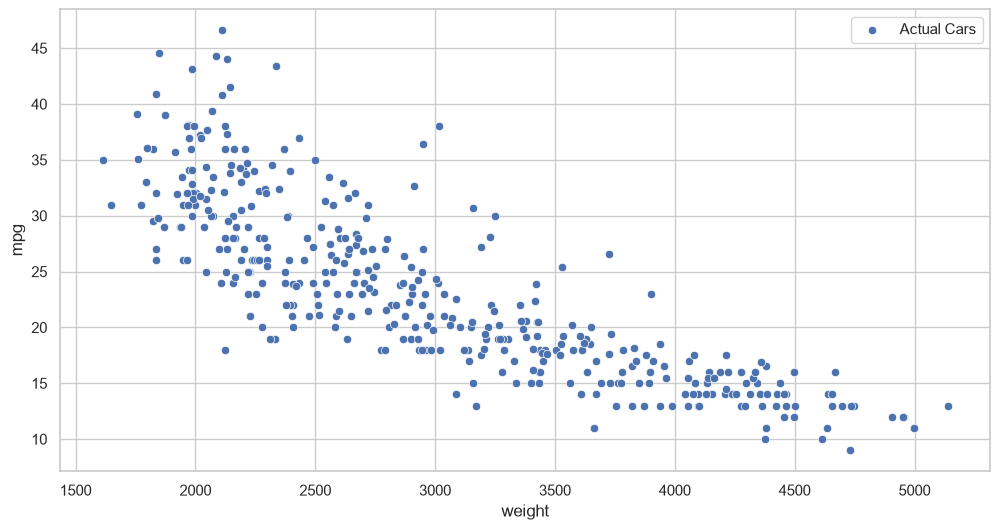

In [29]:
import matplotlib.pyplot as plt

# Plot the raw data
sns.scatterplot(x='weight', y='mpg', data=cars, label='Actual Cars')

# Plot the regression line (for a European car, as baseline)
# The equation is: MPG = const + (weight * -0.007)
weights_sorted = sorted(cars['weight'].dropna())
import numpy as np
# Get the constant and coefficient from the model
const = model.params['const']
coef_weight = model.params['weight']
predicted_mpg = const + coef_weight * np.array(weights_sorted)

plt.plot(weights_sorted, predicted_mpg, color='red', linewidth=3, label='Regression Line (Physics)')
plt.xlabel('Weight (lbs)')
plt.ylabel('Miles Per Gallon (MPG)')
plt.title('Heavier Cars = Lower MPG (The Regression Line Proves It)')
plt.legend()
plt.show()

In [31]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

# Load the dataset and drop any rows with missing values (real-world messiness!)
cars = sns.load_dataset('mpg').dropna()

# Take a peek
print(cars[['mpg', 'weight', 'horsepower', 'origin']].head())

    mpg  weight  horsepower origin
0  18.0    3504       130.0    usa
1  15.0    3693       165.0    usa
2  18.0    3436       150.0    usa
3  16.0    3433       150.0    usa
4  17.0    3449       140.0    usa


In [32]:
mpg = cars['mpg']

mean_mpg = np.mean(mpg)
median_mpg = np.median(mpg)
std_mpg = np.std(mpg, ddof=1)  # ddof=1 for "sample" standard deviation

print(f"Mean MPG: {mean_mpg:.2f}")
print(f"Median MPG: {median_mpg:.2f}")
print(f"Standard Deviation: ±{std_mpg:.2f}")
print(f"Interpretation: A typical car gets {mean_mpg:.2f} MPG, plus or minus {std_mpg:.2f}.")

Mean MPG: 23.45
Median MPG: 22.75
Standard Deviation: ±7.81
Interpretation: A typical car gets 23.45 MPG, plus or minus 7.81.


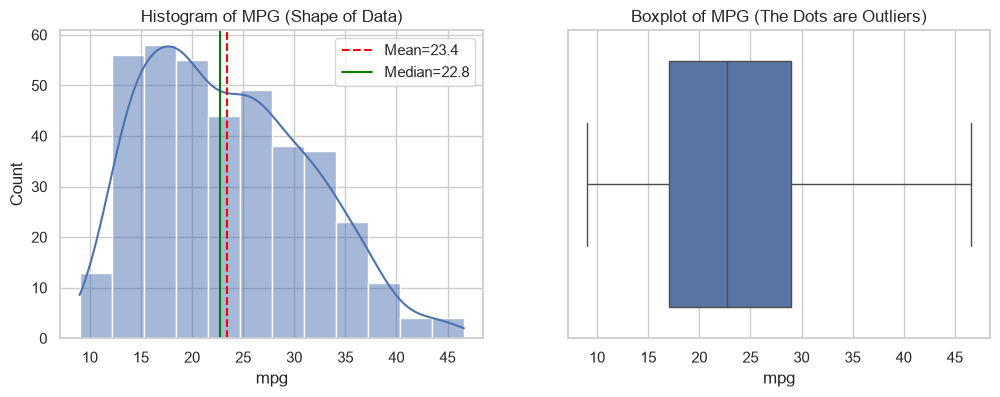

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Histogram (shows shape)
sns.histplot(mpg, kde=True, ax=ax1)
ax1.axvline(mean_mpg, color='red', linestyle='--', label=f'Mean={mean_mpg:.1f}')
ax1.axvline(median_mpg, color='green', linestyle='-', label=f'Median={median_mpg:.1f}')
ax1.legend()
ax1.set_title('Histogram of MPG (Shape of Data)')

# Boxplot (shows outliers explicitly)
sns.boxplot(x=mpg, ax=ax2)
ax2.set_title('Boxplot of MPG (The Dots are Outliers)')
plt.show()